In [19]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from collections import deque
import alpaca_trade_api as tradeapi
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Image
import warnings
import math
warnings.filterwarnings('ignore')
pio.renderers.default = "svg"

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available and being used")
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU instead")

etfs = ['VONG','VOO','VTI','IVV','SPY','IWM','QQQ','XLF']

api = tradeapi.REST('PKI4MOUTF3Z24YPIJPZB7E4MAX', 'AgQQ3uWXYphoiLncrQPe2Vq3NJFeNK4DBk5Qi95q5C8W', base_url='https://paper-api.alpaca.markets', api_version='v2')
account = api.get_account()

GPU is available and being used


In [2]:
#Class ETL
class ETL():
    #This class is designed to process input data to be used by the LSTM or DNN
    def __init__(self, LSTM, file_loc, xCols, yCols, std=None) -> None:
        self.LSTM = LSTM
        self.std = std
        self.xCols = xCols
        self.yCols = yCols
        if file_loc != None:
            self.load_df(file_loc, xCols, yCols)  
        self.add_actuals()          

    def load_df(self, file_loc,xCols, yCols):
        self.df = pd.read_csv(file_loc)
        self.df = self.df.sort_values(by = ['date_time'], ascending = False)
        self.df.reset_index(inplace = True)
        self.df.drop(columns = ['index'], inplace = True)
        self.df['date_time'] = pd.to_datetime(self.df['date_time'])
        #self.set_xy(xCols, yCols)
        self.y_data = self.df[yCols]
        self.addCalcCols()    
        self.x_data = self.df[xCols]    
        new_std = self.normalize_data(True)
        self.std = new_std if self.std == None else self.std 

    def add_actuals(self):
        self.actCols = ['date_time']
        self.modelActs = []
        for x in etfs:
            self.actCols.append(rf'5m_return_{x}')
            self.modelActs.append(rf'5m_return_{x}')

    def addCalcCols(self):
        hour_dist = [self.df['date_time'].dt.hour <= 10, self.df['date_time'].dt.hour <= 12, self.df['date_time'].dt.hour <= 3, True]
        self.df['part_of_day'] = np.select(hour_dist, [0,1,2,3])

        day_dist = [self.df['date_time'].dt.day <= 7, self.df['date_time'].dt.day <= 14, self.df['date_time'].dt.day <= 21, True]
        self.df['part_of_month'] = np.select(day_dist, [0,1,2,3])

        self.add_threshold_data()

    def set_xy(self, xCols, yCols):
        self.x_data = self.df[xCols]
        self.y_data = self.df[yCols]

    def normalize_data(self, updateStd):
        if updateStd:
            std_dict = {}
            for col in self.x_data.columns:
                std_dict.update({(col + '_mean'): self.x_data[col].mean(),(col + '_std'):self.x_data[col].std()})
                self.x_data[col] = (self.x_data[col] - self.x_data[col].mean())/self.x_data[col].std()
            return std_dict
        else:
            for col in self.x_data.columns:
                self.x_data[col] = (self.x_data[col] - self.std_dict[(col + '_mean')])/self.std_dict[(col + '_std')]
            return self.std_dict
        
    def normalize_dataframe(self, df):
        for col in df.columns:
            df[col] = (df[col] - self.std[(col + '_mean')])/self.std[(col + '_std')]
        return df
    
    def save_std(self,file_loc):
        df = pd.DataFrame(self.std, index = [0])
        df.to_csv(file_loc)
    
    def add_threshold_data(self):
        self.y_threshold_data = pd.DataFrame()
        for x in range(len(etfs)):
            self.y_threshold_data[rf'5m_pos_{etfs[x]}'] = np.where(self.y_data[rf'5m_return_{etfs[x]}']>.0001,1,0).astype(float)
            self.y_threshold_data[rf'5m_run_{etfs[x]}'] = np.where(self.y_data[rf'5m_return_{etfs[x]}']>.001,1,0).astype(float)
            self.y_threshold_data[rf'15m_pos_{etfs[x]}'] = np.where(self.y_data[rf'15m_return_{etfs[x]}']>.0001,1,0).astype(float)
            self.y_threshold_data[rf'15m_run_{etfs[x]}'] = np.where(self.y_data[rf'15m_return_{etfs[x]}']>.001,1,0).astype(float)

        for x in range(len(etfs)):
            self.y_threshold_data[rf'5m_return_{etfs[x]}'] = self.y_data[rf'5m_return_{etfs[x]}']

    def split_data(self, percent):
        np.random.seed(0)
        rand_selects = np.random.rand(len(self.y_data))    
        train_indices = []
        test_indices = []
        for x in range(len(self.y_data)):
            train_indices.append(x+1)
            test_indices.append(x+1)
        indices = (rand_selects > percent).astype(float)
        train_indices = indices*(train_indices)
        train_indices = train_indices[train_indices != 0]
        train_indices = train_indices - 1

        test_indices = (1-indices)*(test_indices)
        test_indices = test_indices[test_indices != 0]
        test_indices = test_indices - 1

        self.x_train = torch.index_select(torch.tensor(self.x_data.values), dim = 0, index = torch.tensor(train_indices).long())
        self.x_test = torch.index_select(torch.tensor(self.x_data.values), dim = 0, index = torch.tensor(test_indices).long())

        self.y_train = torch.index_select(torch.tensor(self.y_threshold_data.values), dim = 0, index = torch.tensor(train_indices).long())
        self.y_test = torch.index_select(torch.tensor(self.y_threshold_data.values), dim = 0, index = torch.tensor(test_indices).long())

    def split_data_lstm(self, percent):
        np.random.seed(0)
        rand_selects = np.random.rand(len(self.y_threshold_data))    
        train_indices = []
        test_indices = []
        for x in range(len(self.y_threshold_data)):
            train_indices.append(x+1)
            test_indices.append(x+1)
        indices = (rand_selects > percent).astype(float)
        train_indices = indices*(train_indices)
        train_indices = train_indices[train_indices != 0]
        train_indices = train_indices - 1

        test_indices = (1-indices)*(test_indices)
        test_indices = test_indices[test_indices != 0]
        test_indices = test_indices - 1

        self.x_train = torch.index_select(self.x_data, dim = 0, index = torch.tensor(train_indices).long())
        self.x_test = torch.index_select(self.x_data, dim = 0, index = torch.tensor(test_indices).long())

        self.y_train = torch.index_select(self.y_threshold_data, dim = 0, index = torch.tensor(train_indices).long())
        self.y_test = torch.index_select(self.y_threshold_data, dim = 0, index = torch.tensor(test_indices).long())

    def create_dataset_wlookback(self,dataset_x, dataset_y, lookback):
        X, y = [], []
        for i in range(len(dataset_x)-lookback):
            feature = dataset_y[i:i+lookback].values
            target = dataset_x[i:i+lookback].values
            y.append(feature)
            X.append(target)
        self.x_data = torch.tensor(X)
        self.y_threshold_data = torch.tensor(y)

    def create_dataset_wlookback_x(self,dataset_x, lookback):
        X = []
        for i in range(len(dataset_x)-lookback):
            target = dataset_x[i:i+lookback].values
            X.append(target)
        return torch.tensor(X)


In [67]:
#Class DNN
class DNN():
    def __init__(self,xCols, yCols) -> None:
        self.xCols = xCols
        self.yCols = yCols

    class marketModelDNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.linear_relu_stack = nn.Sequential(
                nn.Linear(114, 1028),
                nn.ReLU(),
                nn.Linear(1028, 512),
                nn.ReLU(),
                nn.Linear(512, 4),
            )
        def forward(self, x):
            x = self.linear_relu_stack(x)
            return x
        
    def initialize_models(self):
        model_vong = self.marketModelDNN()
        model_voo = self.marketModelDNN()
        model_vti = self.marketModelDNN()
        model_ivv = self.marketModelDNN()
        model_spy = self.marketModelDNN()
        model_iwm = self.marketModelDNN()
        model_qqq = self.marketModelDNN()
        model_xlf = self.marketModelDNN()

        self.etf_models = [model_vong, model_voo, model_vti, model_ivv, model_spy, model_iwm, model_qqq, model_xlf]

    def train_models(self, x_model_train_input, y_model_train_full, x_model_test_input, y_model_test_full, epochs):
        for i in range(len(self.etf_models)):    
            #model = marketModel().
            x_model_train = x_model_train_input.to(device).float()
            x_model_test = x_model_test_input.to(device).float()
            model = self.etf_models[i]
            start_col = i*4
            end_col = start_col + 4
            y_model_train = y_model_train_full[:,start_col:end_col].to(device).float()
            y_model_test = y_model_test_full[:,start_col:end_col].to(device).float()
            model.cuda()
            optimizer = optim.Adam(model.parameters(), lr = .001)
            loss_fn = nn.MSELoss()
            loader = data.DataLoader(data.TensorDataset(x_model_train, y_model_train), shuffle=True, batch_size=512)
            
            n_epochs = epochs
            for epoch in range(n_epochs):
                model.train()
                for X_batch, y_batch in loader:
                    y_pred = model(X_batch)
                    loss = loss_fn(y_pred, y_batch)
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    torch.cuda.empty_cache()
                # Validation
                if epoch % 10 != 0:
                    continue
                model.eval()
                with torch.no_grad():
                    y_pred = model(x_model_train.float())
                    train_rmse = torch.sqrt(loss_fn(y_pred, y_model_train))
                    y_pred = model(x_model_test)
                    test_rmse = torch.sqrt(loss_fn(y_pred, y_model_test))
                    cpu_test_rmse = test_rmse.cpu()
                    cpu_train_rmse = train_rmse.cpu()
                #torch.cuda.empty_cache()
                print("Epoch %d of %s: train RMSE %.4f, test RMSE %.4f" % (epoch, etfs[i],cpu_test_rmse, cpu_train_rmse))

    def save_models(self,folder_loc,surr_name):
        #Save model
        for x in range(len(self.etf_models)):    
            model = self.etf_models[x]
            torch.save(model.state_dict(), rf'{folder_loc}\model_{etfs[x]}_{surr_name}')

    def load_models(self,folder_loc,surr_name):
        self.initialize_models()
        for x in range(len(etfs)):
            self.etf_models[x].load_state_dict(torch.load(rf'{folder_loc}\model_{etfs[x]}_{surr_name}'))
            self.etf_models[x].cuda()
            self.etf_models[x].eval()

    def get_predictions(self, x_data):
        x_model_data = torch.tensor(x_data[self.xCols].values)
        for x in range(len(etfs)):
            model = self.etf_models[x]
            if x == 0:
                y_pred = model(torch.tensor(x_model_data).float().cuda())        
            else:
                y_pred = torch.cat([y_pred,model(torch.tensor(x_model_data).float().cuda())], dim = 1)

        predictions = pd.DataFrame(y_pred.cpu().detach().numpy())
        #act_cols = []
        #for x in etfs:
        #    act_cols.append(rf'5m_return_{x}')
        #actual_returns = y_data[act_cols]
        return predictions#, actual_returns
    
    def show_accuracy_agg(self,actual_returns_input, predictions_input):
        actual_returns = actual_returns_input.copy()
        predictions = predictions_input.copy()
        for i in range(len(etfs)):
            actual_returns[rf'accuracy_{etfs[i]}'] = np.where(((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0))|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)),1,0)
            actual_returns[rf'inacc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0),1,0)
            actual_returns[rf'acc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] >= 0),1,0)
            actual_returns[rf'inacc_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0)),1,0)
        
        accuracy = []
        cols = []
        for i in range(len(etfs)):
            accuracy.append((actual_returns[rf'accuracy_{etfs[i]}'].sum()/(actual_returns[rf'inacc_{etfs[i]}'].sum()+actual_returns[rf'accuracy_{etfs[i]}'].sum())))
            cols.append(rf'{etfs[i]} All Predictions')
            accuracy.append(1 - (actual_returns[rf'inacc_HC_{etfs[i]}'].sum()/(len(predictions[(predictions[rf'5m_pos_{etfs[i]}'] > .85)]))))
            cols.append(rf'{etfs[i]} High Confidence Acc')
        for i in range(len(accuracy)):
            accuracy[i] = accuracy[i]*100

        fig, ax = plt.subplots(figsize=(25, 10))
        sns.barplot( x=cols, y=accuracy, ax = ax, color='royalblue')
        ax.set_title('Accuracy of model prediction of positive market movements', fontsize = 25)
        ax.set_ylabel('% Accuracy',fontsize = 18)
        ax.set_xlabel('ETF model Predictions',fontsize = 18)
        ax.yaxis.set_major_formatter(PercentFormatter())
        plt.subplots_adjust(top=0.9)
        plt.xticks(rotation=45, horizontalalignment='right')
        plt.show()

    def show_accuracy_yearly(self, actual_returns_input, predictions_input,date_column):
        actual_returns = actual_returns_input.copy()
        predictions = predictions_input.copy()
        actual_returns['date'] = date_column
        actual_returns['Year'] = pd.to_datetime(actual_returns['date']).dt.year
        agg_dict = {}

        for i in range(len(etfs)):
            actual_returns[rf'accuracy_{etfs[i]}'] = np.where(((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0))|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)),1,0)
            actual_returns[rf'inacc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0),1,0)
            actual_returns[rf'acc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] >= 0),1,0)
            actual_returns[rf'inacc_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0)),1,0)
        
        for i in range(len(etfs)):
            agg_dict.update({rf'accuracy_{etfs[i]}':'sum'})
            agg_dict.update({rf'inacc_HC_{etfs[i]}':'sum'})
            agg_dict.update({rf'inacc_{etfs[i]}':'sum'})
            agg_dict.update({rf'acc_HC_{etfs[i]}':'sum'})
        accuracy_time =actual_returns.groupby(actual_returns['Year']).agg(agg_dict).reset_index()
        cols = []
        cols_HC = []
        for i in range(len(etfs)):
            accuracy_time[rf'{etfs[i]}'] = 100*(accuracy_time[rf'accuracy_{etfs[i]}']/(accuracy_time[rf'accuracy_{etfs[i]}'] + accuracy_time[rf'inacc_{etfs[i]}']))
            cols.append(rf'{etfs[i]}')
            accuracy_time[rf'HC_{etfs[i]}'] = 100*(accuracy_time[rf'acc_HC_{etfs[i]}']/(accuracy_time[rf'inacc_HC_{etfs[i]}'] + accuracy_time[rf'acc_HC_{etfs[i]}']))
            cols_HC.append(rf'HC_{etfs[i]}')

        fig, ax = plt.subplots(figsize=(25, 10))
        cols.append('Year')
        accuracy_time_tmp = pd.melt(accuracy_time[cols], ['Year'])
        #for etf in etfs:
        #    sns.lineplot()
        sns.lineplot(data = accuracy_time_tmp, x='Year', y = 'value', ax = ax, hue = 'variable')
        ax.set_title('Accuracy by Year', fontsize = 25)
        ax.yaxis.set_major_formatter(PercentFormatter())
        plt.ylim(0, 100)
        plt.show()

        fig, ax = plt.subplots(figsize=(25, 10))
        cols_HC.append('Year')
        accuracy_time_tmp = pd.melt(accuracy_time[cols_HC], ['Year'])
        sns.lineplot(data = accuracy_time_tmp, x='Year', y = 'value', ax = ax, hue = 'variable')
        ax.set_title('High Confidence Accuracy by Year', fontsize = 25)
        ax.yaxis.set_major_formatter(PercentFormatter())
        plt.ylim(0, 100)
        plt.show()

 


In [4]:
#Class LSTM

class LSTM_Network():
    def __init__(self,xCols, yCols, lookback) -> None:
        self.xCols = xCols
        self.yCols = yCols
        self.lookback = lookback
    
    def initialize_models(self):
        model_vong = self.marketModel()
        model_voo = self.marketModel()
        model_vti = self.marketModel()
        model_ivv = self.marketModel()
        model_spy = self.marketModel()
        model_iwm = self.marketModel()
        model_qqq = self.marketModel()
        model_xlf = self.marketModel()

        self.etf_models = [model_vong, model_voo, model_vti, model_ivv, model_spy, model_iwm, model_qqq, model_xlf]

    class marketModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size=18, hidden_size=128, num_layers=1, batch_first=True, dropout = .02)
            self.linear = nn.Linear(128, 4)
        def forward(self, x):
            x = torch.flip(x, dims=[1])
            x, _ = self.lstm(x)
            x = self.linear(x)
            x = x[:,-1,:]
            return x
        
    def train_models(self, x_model_train_input, y_model_train_full, x_model_test_input, y_model_test_full, epochs):
        x_model_train = x_model_train_input.to(device).float()
        x_model_test = x_model_test_input.to(device).float()
        y_model_train_full = y_model_train_full.to(device).float()
        y_model_test_full = y_model_test_full.to(device).float()
        torch.set_grad_enabled(True)
        for i in range(len(self.etf_models)):    
            #model = marketModel()
            model = self.etf_models[i]
            start_col = i*4
            end_col = start_col + 4
            y_model_train = y_model_train_full[:,start_col:end_col]
            y_model_test = y_model_test_full[:,start_col:end_col]
            model.cuda()
            optimizer = optim.Adam(model.parameters(), lr = .005)
            loss_fn = nn.MSELoss()
            loader = data.DataLoader(data.TensorDataset(x_model_train, y_model_train), shuffle=False, batch_size=512)
            
            n_epochs = epochs
            for epoch in range(n_epochs):
                model.train()
                for X_batch, y_batch in loader:
                    y_pred = model(X_batch)
                    loss = loss_fn(y_pred, y_batch)                    
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                    torch.cuda.empty_cache()
                # Validation
                if epoch % 10 != 0:
                    torch.cuda.empty_cache()
                    continue
                model.eval()
                with torch.no_grad():
                    #y_pred = torch.tensor(self.get_predictions(x_model_train)).to(device).float()
                    #train_rmse = torch.sqrt(loss_fn(y_pred, y_model_train))
                    y_pred = model(x_model_test)
                    test_rmse = torch.sqrt(loss_fn(y_pred, y_model_test))
                    cpu_test_rmse = test_rmse.cpu()
                    cpu_train_rmse = test_rmse.cpu()
                torch.cuda.empty_cache()
                print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, cpu_test_rmse, cpu_train_rmse))
    
    def save_models(self,folder_loc,surr_name):
        #Save model
        for x in range(len(self.etf_models)):    
            model = self.etf_models[x]
            torch.save(model.state_dict(), rf'{folder_loc}\model_{etfs[x]}_{surr_name}')
            
    def load_models(self,folder_loc,surr_name):
        self.initialize_models()
        for x in range(len(etfs)):
            self.etf_models[x].load_state_dict(torch.load(rf'{folder_loc}\model_{etfs[x]}_{surr_name}'))
            self.etf_models[x].cuda()
            self.etf_models[x].eval()

    def get_predictions(self, x_data):
        with torch.no_grad():
            x_model_data = x_data.to(device).float()#torch.tensor(x_data[self.xCols].values)
            for x in range(len(etfs)):
                model = self.etf_models[x]
                if x == 0:
                    y = math.ceil(x_model_data.shape[0]/10000)
                    for a in range(y):
                        if a == 0:
                            y_pred = model(x_model_data[(a*10000):min(x_model_data.shape[0],((a+1)*10000)),:,:])[:,:]     
                        else:
                            y_pred = torch.cat([y_pred,model(x_model_data[(a*10000):min(x_model_data.shape[0],((a+1)*10000)),:,:])[:,:]], dim = 0)
                else:
                    y = math.ceil(x_model_data.shape[0]/10000)
                    for a in range(y):
                        if a == 0:
                            y_pred_new = model(x_model_data[(a*10000):min(x_model_data.shape[0],((a+1)*10000)),:,:])[:,:]     
                        else:
                            y_pred_new = torch.cat([y_pred_new,model(x_model_data[(a*10000):min(x_model_data.shape[0],((a+1)*10000)),:,:])[:,:]], dim = 0)
                    y_pred = torch.cat([y_pred,y_pred_new], dim = 1)

        predictions = pd.DataFrame(y_pred.cpu().detach().numpy())
        #act_cols = []
        #for x in etfs:
        #    act_cols.append(rf'5m_return_{x}')
        #actual_returns = y_data[act_cols]
        return predictions#, actual_returns
    
    def show_accuracy_agg(self,actual_returns_input, predictions_input):
        actual_returns = actual_returns_input.copy()
        predictions = predictions_input.copy()
        for i in range(len(etfs)):
            actual_returns[rf'accuracy_{etfs[i]}'] = np.where(((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0))|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)),1,0)
            actual_returns[rf'inacc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0),1,0)
            actual_returns[rf'acc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] >= 0),1,0)
            actual_returns[rf'inacc_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0)),1,0)
        
        accuracy = []
        cols = []
        for i in range(len(etfs)):
            accuracy.append((actual_returns[rf'accuracy_{etfs[i]}'].sum()/(actual_returns[rf'inacc_{etfs[i]}'].sum()+actual_returns[rf'accuracy_{etfs[i]}'].sum())))
            cols.append(rf'{etfs[i]} All Predictions')
            accuracy.append(1 - (actual_returns[rf'inacc_HC_{etfs[i]}'].sum()/(len(predictions[(predictions[rf'5m_pos_{etfs[i]}'] > .85)]))))
            cols.append(rf'{etfs[i]} High Confidence Acc')

        bar_trace = go.Bar(x=cols, y=accuracy)
        fig = go.Figure(data=[bar_trace])
        fig.update_layout(title='Accuracy of model prediction of positive market movements', xaxis_title='ETF model Predictions', yaxis_title='% Accuracy')
        fig.update_layout(yaxis_tickformat='.0%')
        fig.show()

    def show_accuracy_yearly(self, actual_returns_input, predictions_input,date_column):
        actual_returns = actual_returns_input.copy()
        predictions = predictions_input.copy()
        actual_returns['date'] = date_column
        actual_returns['Year'] = pd.to_datetime(actual_returns['date']).dt.year
        agg_dict = {}

        for i in range(len(etfs)):
            actual_returns[rf'accuracy_{etfs[i]}'] = np.where(((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0))|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)),1,0)
            actual_returns[rf'inacc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0),1,0)
            actual_returns[rf'acc_HC_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .85)&(actual_returns[rf'5m_return_{etfs[i]}'] >= 0),1,0)
            actual_returns[rf'inacc_{etfs[i]}'] = np.where((predictions[rf'5m_pos_{etfs[i]}'] > .5)&(actual_returns[rf'5m_return_{etfs[i]}'] < 0)|((predictions[rf'5m_pos_{etfs[i]}'] < .5)&(actual_returns[rf'5m_return_{etfs[i]}'] > 0)),1,0)
        
        for i in range(len(etfs)):
            agg_dict.update({rf'accuracy_{etfs[i]}':'sum'})
            agg_dict.update({rf'inacc_HC_{etfs[i]}':'sum'})
            agg_dict.update({rf'inacc_{etfs[i]}':'sum'})
            agg_dict.update({rf'acc_HC_{etfs[i]}':'sum'})
        accuracy_time =actual_returns.groupby(actual_returns['Year']).agg(agg_dict).reset_index()
        cols = []
        cols_HC = []
        for i in range(len(etfs)):
            accuracy_time[rf'{etfs[i]}'] = accuracy_time[rf'accuracy_{etfs[i]}']/(accuracy_time[rf'accuracy_{etfs[i]}'] + accuracy_time[rf'inacc_{etfs[i]}'])
            cols.append(rf'{etfs[i]}')
            accuracy_time[rf'HC_{etfs[i]}'] = accuracy_time[rf'acc_HC_{etfs[i]}']/(accuracy_time[rf'inacc_HC_{etfs[i]}'] + accuracy_time[rf'acc_HC_{etfs[i]}'])
            cols_HC.append(rf'HC_{etfs[i]}')

        fig_accuracy = px.line(accuracy_time, x='Year', y=cols, title='Accuracy by Year')
        fig_accuracy.update_yaxes(range=[0, 1])
        fig_accuracy.update_yaxes(tickformat=".0%") 
        fig_accuracy.show()

        fig_accuracy = px.line(accuracy_time, x='Year', y=cols_HC, title='High Confidence Accuracy by Year')
        fig_accuracy.update_yaxes(range=[0, 1])
        fig_accuracy.update_yaxes(tickformat=".0%") 
        fig_accuracy.show()

In [5]:
#Class DQN
class Q_Network():
    def __init__(self):
        self.model = None        

    class DQN(nn.Module):
        def __init__(self, input_size, output_size,Q_Network):
            super(Q_Network.DQN, self).__init__()        
            self.fc1_x = nn.Linear(input_size, 256) 
            self.dropout1 = nn.Dropout(p=0.25)
            self.fc3 = nn.Linear(256, 256)
            self.dropout2 = nn.Dropout(p=0.1)
            self.fc4 = nn.Linear(256, output_size)

        def forward(self, x):
            x = torch.relu(self.fc1_x(x))
            x = self.dropout1(x)
            x = torch.relu(self.fc3(x))
            x = self.dropout2(x)
            x = self.fc4(x)
            return x

    class TradingEnvironmentReturns:
        def __init__(self, projected_returns_data, actual_returns_data, initial_balance, window_size):
            self.projected_returns_data = projected_returns_data
            self.actual_returns_data = actual_returns_data
            self.initial_balance = initial_balance
            self.window_size = window_size
            self.current_step = self.window_size
            self.num_stocks = actual_returns_data.shape[1]
            self.state_dim = projected_returns_data.shape[1]
            self.actions = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  # 8: hold, 0-7: buy highest projected stock, 9: sell all

        def calculate_projected_returns(self, data):
            returns = (data[1:] - data[:-1]) / data[:-1]
            return np.nan_to_num(returns)

        def reset(self):
            self.current_step = self.window_size
            self.balance = np.array([self.initial_balance] * (self.num_stocks+1), dtype=np.float32)
            self.balance = self.balance*0
            self.balance[self.num_stocks] = self.initial_balance
            state = self.projected_returns_data[self.current_step - self.window_size:self.current_step]
            return state

        def step(self, action, current_state):
            next_state = self.projected_returns_data[self.current_step-1:self.current_step]
            if action == 8: #hold
                start_balances = self.balance.sum()
                for i in range(self.num_stocks):
                    self.balance[i] += self.balance[i] * self.actual_returns_data[self.current_step-1][i]
                reward = self.balance.sum() - start_balances 

            elif action == 9:
                start_balances = self.balance.sum()
                for i in range(self.num_stocks):
                    self.balance[i] = self.balance[i] 
                total_assets = self.balance.sum()
                self.balance = self.balance*0
                self.balance[-1] = total_assets * .9999 
                reward = self.balance.sum() - start_balances

            else:  # move assets to highest 5m projection    
                start_balances = self.balance.sum()
                #decrease balances by bid/ask spreads                
                stock_pick = action
                curr_invest = self.balance.argmax()
                for i in range(self.num_stocks):
                    if(i != curr_invest):
                        self.balance[i] = self.balance[i] * .9998            
                total_assets = self.balance.sum()
                self.balance = self.balance*0
                self.balance[stock_pick] = total_assets 
                #apply market returns
                for i in range(self.num_stocks):
                    self.balance[i] += self.balance[i] * self.actual_returns_data[self.current_step][i]
                reward = self.balance.sum() - start_balances            


            self.current_step += 1
            done = self.current_step >= len(self.projected_returns_data) - 1
            if  pd.isna(reward):
                stop = True
            if np.isposinf(reward):
                stop = True
            if np.isposinf(self.balance.sum()):
                stop = True

            next_state = self.projected_returns_data[self.current_step:self.current_step + 1]
            return next_state, reward, done, current_state

        def get_current_state(self):
            # Provide the current state data here
            return self.projected_returns_data[self.current_step - 1:self.current_step]

    class TradingEnvironmentPoints:
        def __init__(self, projected_returns_data, actual_returns_data, initial_balance, window_size):
            self.projected_returns_data = projected_returns_data
            self.actual_returns_data = actual_returns_data
            self.initial_balance = initial_balance
            self.window_size = window_size
            self.current_step = self.window_size
            self.num_stocks = actual_returns_data.shape[1]
            self.state_dim = projected_returns_data.shape[1]
            self.actions = [0, 1, 2]  # 0: hold, 1 buy, 2: sell all

        def calculate_projected_returns(self, data):
            returns = (data[1:] - data[:-1]) / data[:-1]
            return np.nan_to_num(returns)

        def reset(self):
            self.current_step = self.window_size
            self.balance = np.array([self.initial_balance] * (self.num_stocks+1), dtype=np.float32)
            self.balance = self.balance*0
            self.balance[self.num_stocks] = self.initial_balance
            state = self.projected_returns_data[self.current_step - self.window_size:self.current_step]
            return state.to(device)

        def step(self, action, current_state):
            if (self.current_step % 78 == 0):
                self.balance = self.balance*0
                self.balance[-1] = 1
            next_state = self.projected_returns_data[self.current_step-1:self.current_step].to(device)        
            current_state = torch.tensor(current_state, dtype=torch.float32).to(device)

            stock_pred = torch.zeros(8).cuda()
            for i in range(8):
                start = i*4
                stop = start + 5
                stock_pred[i] += (next_state[0,start:stop].mean())
            stock_pick = stock_pred.argmax()
            curr_invest = self.balance.argmax()

            if curr_invest == 8 and self.actual_returns_data[self.current_step-1][stock_pick] >= .0:
                reward_1 = 1
            elif self.actual_returns_data[self.current_step-1][stock_pick] - self.actual_returns_data[self.current_step-1][curr_invest]  >= .001 and self.actual_returns_data[self.current_step-1][stock_pick] >= .007:
                reward_1 = 5
            elif self.actual_returns_data[self.current_step-1][stock_pick] - self.actual_returns_data[self.current_step-1][curr_invest]  >= .0005 and self.actual_returns_data[self.current_step-1][stock_pick] >= .005:
                reward_1 = 0
            elif self.actual_returns_data[self.current_step-1][stock_pick] - self.actual_returns_data[self.current_step-1][curr_invest] <= 0:
                reward_1 = -1
            elif self.actual_returns_data[self.current_step-1][stock_pick] - self.actual_returns_data[self.current_step-1][curr_invest] <= .05:
                reward_1 = -5      
            else:
                reward_1 = 0

            if curr_invest == 8 and self.actual_returns_data[self.current_step-1][stock_pick] <= 0:
                reward_0 = 1
            elif curr_invest == 8 and self.actual_returns_data[self.current_step-1][stock_pick] > 0:
                reward_0 = 5

            if self.balance.argmax() == 8 and self.actual_returns_data[self.current_step-1][stock_pick] < 0:
                reward_2 = 0
            elif self.actual_returns_data[self.current_step-1][self.balance.argmax()] < 0:
                reward_2 = 2
            else:
                reward_2 = 0

            if action == 1:
                self.balance = self.balance*0
                self.balance[(stock_pick)] = 1
            elif action == 2:     
                self.balance = self.balance*0
                self.balance[-1] = 1

            if action == 0:
                reward = reward_0
            elif action == 1:
                reward = reward_1
            else:
                reward = reward_2

            self.current_step += 1
            done = self.current_step >= len(self.projected_returns_data) - 1
            next_state = self.projected_returns_data[self.current_step:self.current_step + 1].to(device)
            return next_state, reward, done, current_state

        def get_current_state(self):
            return self.projected_returns_data[self.current_step - 1:self.current_step]
        
    class DQNAgent():
        def __init__(self, input_size, state_size, output_size, Q_Network):
            self.input_size = input_size - state_size
            self.state_size = state_size
            self.output_size = output_size
            self.memory = deque(maxlen=10000)
            self.gamma = .75  # Discount factor for future rewards
            self.epsilon = 1.0  # Exploration rate
            self.epsilon_decay = 0.9999
            self.epsilon_min = 0.05
            self.model = Q_Network.DQN(input_size,output_size,Q_Network).to(device)
            self.optimizer = optim.Adam(self.model.parameters(), lr=0.0001,betas=(0.9, 0.999))

        def select_action(self, state, current_state):
            if np.random.rand() <= self.epsilon:
                return np.random.choice(self.output_size)
            state = torch.tensor(state, dtype=torch.float32).view(-1, self.input_size)
            current_state = torch.tensor(current_state, dtype=torch.float32).view(-1, self.state_size)
            with torch.no_grad():
                q_values = self.model(torch.cat([state,current_state], dim = 1))
                return torch.argmax(q_values).item()

        def remember(self, state, action, reward, next_state, next_current_state, done):
            self.memory.append((state, action, [reward], next_state, next_current_state, done))

        def replay(self, batch_size):
            if len(self.memory) < batch_size:
                return

            batch = np.random.choice(len(self.memory), batch_size, replace=False)
            states, actions, rewards, next_states, next_current_states, dones = zip(*[self.memory[i] for i in batch])

            states = torch.cat([torch.tensor(state, dtype=torch.float32).to(device) for state in states], dim=0)
            actions = torch.tensor(actions, dtype=torch.int64).view(batch_size, -1).to(device)
            rewards = torch.tensor(rewards, dtype=torch.float32).view(batch_size, -1).to(device)
            next_states = torch.cat([torch.tensor(next_state, dtype=torch.float32).view(1, -1).to(device) for next_state in next_states], dim=0)
            next_current_states = torch.cat([torch.tensor(next_current_state, dtype=torch.float32).view(1, -1).to(device) for next_current_state in next_current_states], dim=0)
            dones = torch.tensor(dones, dtype=torch.bool).view(batch_size, -1).to(device)
            
            current_q_values = self.model(torch.cat([states,next_current_states], dim = 1)).gather(1, actions)

            with torch.no_grad():
                next_q_values = self.model(torch.cat([states,next_current_states], dim = 1)).max(1)[0].view(batch_size, -1)
                target_q_values = rewards + self.gamma * next_q_values * ~dones

            loss = F.mse_loss(current_q_values, target_q_values)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            if self.epsilon > self.epsilon_min:
                self.epsilon *= self.epsilon_decay
        
    def train_model(self,projected_returns_data, actual_returns_data, initial_balance, window_size, num_episodes, batch_size):
        projected_returns_data = torch.tensor(projected_returns_data, dtype=torch.float32).to(device)
        actual_returns_data = torch.tensor(actual_returns_data, dtype=torch.float32).to(device)

        env = self.TradingEnvironmentPoints(projected_returns_data, actual_returns_data, initial_balance, window_size)
        agent = self.DQNAgent((env.state_dim + 9), 9, len(env.actions),self)

        for episode in range(num_episodes):
            state = env.reset().to(device)
            current_state = (env.balance > 0).astype('float32')
            current_state = torch.tensor(current_state, dtype=torch.float32).to(device)
            total_reward = 0

            while True:
                current_state = (env.balance > 0).astype('float32')
                state = torch.tensor(state, dtype=torch.float32).to(device)
                current_state = torch.tensor(current_state, dtype=torch.float32).to(device)
                action = agent.select_action(state, current_state)
                next_state, reward, done, next_current_state = env.step(action, current_state)
                total_reward += reward
                agent.remember(state, action, reward, next_state, current_state, done)
                state = next_state
                if done:
                    break
                agent.replay(batch_size)
            print(f"Episode {episode + 1}/{num_episodes}, Total Reward: {total_reward}")
        return agent

    def train_model_returns(self,projected_returns_data, actual_returns_data, initial_balance, window_size, num_episodes, batch_size):
        projected_returns_data = torch.tensor(projected_returns_data, dtype=torch.float32).to(device)
        actual_returns_data = torch.tensor(actual_returns_data, dtype=torch.float32).to(device)

        env = self.TradingEnvironmentReturns(projected_returns_data, actual_returns_data, initial_balance, window_size)
        agent = self.DQNAgent((env.state_dim + 9), 9, len(env.actions),self)

        for episode in range(num_episodes):
            state = env.reset().to(device)
            current_state = (env.balance > 0).astype('float32')
            current_state = torch.tensor(current_state, dtype=torch.float32).to(device)
            total_reward = 0

            while True:
                current_state = (env.balance > 0).astype('float32')
                state = torch.tensor(state, dtype=torch.float32).to(device)
                current_state = torch.tensor(current_state, dtype=torch.float32).to(device)
                action = agent.select_action(state, current_state)
                next_state, reward, done, next_current_state = env.step(action, current_state)
                total_reward += reward
                agent.remember(state, action, reward, next_state, current_state, done)
                state = next_state

                if done:
                    break

                agent.replay(batch_size)

            print(f"Episode {episode + 1}/{num_episodes}, Total Reward: {total_reward}")
        return agent
    
    def build_model(self,projected_returns_data, actual_returns_data, initial_balance, window_size, num_episodes, batch_size):
        self.model = self.train_model(projected_returns_data, actual_returns_data, initial_balance, window_size, num_episodes, batch_size)
        self.model = self.model.model
        self.model.eval().cuda()

    def build_model_returns(self,projected_returns_data, actual_returns_data, initial_balance, window_size, num_episodes, batch_size):
        self.model = self.train_model_returns(projected_returns_data, actual_returns_data, initial_balance, window_size, num_episodes, batch_size)
        self.model = self.model.model
        self.model.eval().cuda()

    def load_model(self,save_loc):
        self.model = self.DQN(41, 3,Q_Network)
        self.model.load_state_dict(torch.load(save_loc))
        self.model.eval().cuda()

    def save_model(self, save_loc):
        if self.model == None:
            print('No model to save')
        else:
            torch.save(self.model.state_dict(), save_loc)

    def eval_model(self,y_preds_input, actual_returns,spread):
        y_preds = torch.tensor(y_preds_input).float().cuda()
        invest = 1
        state = torch.tensor([0,0,0,0,0,0,0,0,1]).cuda()
        df_returns = pd.DataFrame()
        actions = [0,0,0]
        df_returns = {}
        for timestep in range(len(y_preds)):
            q_values = self.get_Q_Values(y_preds[timestep],state)
            if q_values.argmax() == 0:
                inv = state.argmax()
                if inv == 8:
                    ret = 0
                else:
                    ret = actual_returns[rf'5m_return_{etfs[inv]}'][timestep]
                invest = invest*(1+ret)
                actions[0] = actions[0] + 1
            elif q_values.argmax() == 1:
                inv = y_preds[timestep][[0,4,8,12,16,20,24,28]].argmax()
                ret = actual_returns[rf'5m_return_{etfs[inv]}'][timestep] - (2*spread if state.argmax != 8 else spread)
                state = torch.tensor([0,0,0,0,0,0,0,0,0]).cuda()
                state[inv] = 1
                invest = invest*(1+ret)
                actions[1] = actions[1] + 1
            else:                
                ret = 0 - (spread if state.argmax != 8 else 0)
                actions[2] = actions[2] + 1
                state = torch.tensor([0,0,0,0,0,0,0,0,1]).cuda()
            df_returns.update({actual_returns['date_time'][timestep]:ret})
        return df_returns, actions
    
    def eval_model_return(self,y_preds_input, actual_returns,spread):
        y_preds = torch.tensor(y_preds_input).float().cuda()
        invest = 1
        state = torch.tensor([0,0,0,0,0,0,0,0,1]).cuda()
        df_returns = pd.DataFrame()
        actions = [0,0,0,0,0,0,0,0,0,0]
        df_returns = {}
        for timestep in range(len(y_preds)):
            q_values = self.get_Q_Values(y_preds[timestep],state)
            if q_values.argmax() == 8:
                inv = state.argmax()
                if inv == 8:
                    ret = 0
                else:
                    ret = actual_returns[rf'5m_return_{etfs[inv]}'][timestep]
                invest = invest*(1+ret)
                actions[0] = actions[0] + 1
            elif q_values.argmax() == 9:
                state = torch.tensor([0,0,0,0,0,0,0,0,1]).cuda()
                ret = 0 - (spread if state.argmax != 8 else 0)
                actions[2] = actions[2] + 1                
            else:                
                inv = q_values.argmax() 
                ret = actual_returns[rf'5m_return_{etfs[inv]}'][timestep] - (spread if state.argmax != 8 else 0)
                state = torch.tensor([0,0,0,0,0,0,0,0,0]).cuda()
                state[inv] = 1
                invest = invest*(1+ret)
                actions[1] = actions[1] + 1
            df_returns.update({actual_returns['date_time'][timestep]:ret})
        return df_returns, actions
    
    def display_return_graphs(self,y_preds_input, actual_returns,spread):
        df_returns, actions = self.eval_model(y_preds_input, actual_returns,spread)
        cols = ['Hold','Buy','Sell']
        total_actions = sum(actions)
        actions_perc = [x/total_actions for x in actions]
        bar_trace = go.Bar(x=cols, y=actions_perc)
        fig = go.Figure(data=[bar_trace])
        fig.update_layout(title='Accuracy of model prediction of positive market movements', xaxis_title='ETF model Predictions', yaxis_title='% Accuracy')
        fig.update_layout(yaxis_tickformat='.0%')
        fig.show()
        df_returninfo = pd.DataFrame()
        df_returninfo['date_time'] = actual_returns['date_time']
        for x in range(len(etfs)):
            df_returninfo[rf'{etfs[x]}'] = actual_returns[rf'5m_return_{etfs[x]}']
        df_returninfo['DQN'] = df_returninfo['date_time'].map(df_returns)
        #get montly returns
        final_returns = df_returninfo.copy()
        final_returns['Year'] = pd.to_datetime(final_returns['date_time']).dt.year
        final_returns['Month'] = pd.to_datetime(final_returns['date_time']).dt.month
        agg_dict = {'DQN':'prod'}
        final_returns['DQN'] = final_returns['DQN'] + 1
        for x in etfs:
            final_returns[rf'{x}'] = 1 + final_returns[rf'{x}'] 
            agg_dict.update({rf'{x}':'prod'})

        final_returns = final_returns.groupby(['Year','Month']).agg(agg_dict).reset_index()
        final_returns['DQN'] = (final_returns['DQN'])**12 -1
        for x in etfs:
            final_returns[rf'{x}'] = (final_returns[rf'{x}'])**12 - 1
        cols = final_returns.columns.drop(['Year','Month'])
        final_returns['day'] = 1
        final_returns['date'] = pd.to_datetime(final_returns[['Year','Month','day']])
        fig_accuracy = px.line(final_returns, x='date', y=cols, title='Returns by Month')
        fig_accuracy.update_yaxes(range=[-.2, 5])
        fig_accuracy.update_yaxes(tickformat=".0%") 
        
        fig_accuracy.show()

        final_returns_ann = df_returninfo.copy()
        final_returns_ann['Year'] = pd.to_datetime(final_returns_ann['date_time']).dt.year
        final_returns_ann['Month'] = pd.to_datetime(final_returns_ann['date_time']).dt.month
        agg_dict = {'DQN':'prod'}
        final_returns_ann['DQN'] = final_returns_ann['DQN'] + 1
        for x in etfs:
            final_returns_ann[rf'{x}'] = 1 + final_returns_ann[rf'{x}'] 
            agg_dict.update({rf'{x}':'prod'})

        final_returns_ann = final_returns_ann.groupby(['Year']).agg(agg_dict).reset_index()
        final_returns_ann['DQN'] = (final_returns_ann['DQN']) -1
        for x in etfs:
            final_returns_ann[rf'{x}'] = (final_returns_ann[rf'{x}']) - 1
        cols = final_returns_ann.columns.drop(['Year'])
        #final_returns_ann['date'] = pd.to_datetime(final_returns_ann[['Year','Month','day']])
        fig_accuracy_ann = px.line(final_returns_ann, x='Year', y=cols, title='Returns by Year')
        fig_accuracy_ann.update_yaxes(range=[-.2, 5])
        fig_accuracy_ann.update_yaxes(tickformat=".0%") 
        fig_accuracy_ann.show()

        print(final_returns_ann.head(25))

    def display_graphs_ret_model(self,y_preds_input, actual_returns,spread):
        df_returns, actions = self.eval_model_return(y_preds_input, actual_returns,spread)
        cols = ['VONG','VOO','VTI','IVV','SPY','IWM','QQQ','XLF','Hold','Sell']
        total_actions = sum(actions)
        actions_perc = [x/total_actions for x in actions]
        bar_trace = go.Bar(x=cols, y=actions_perc)
        fig = go.Figure(data=[bar_trace])
        fig.update_layout(title='Accuracy of model prediction of positive market movements', xaxis_title='ETF model Predictions', yaxis_title='% Accuracy')
        fig.update_layout(yaxis_tickformat='.0%')
        fig.show()
        df_returninfo = pd.DataFrame()
        df_returninfo['date_time'] = actual_returns['date_time']
        for x in range(len(etfs)):
            df_returninfo[rf'{etfs[x]}'] = actual_returns[rf'5m_return_{etfs[x]}']
        df_returninfo['DQN'] = df_returninfo['date_time'].map(df_returns)
        #get montly returns
        final_returns = df_returninfo.copy()
        final_returns['Year'] = pd.to_datetime(final_returns['date_time']).dt.year
        final_returns['Month'] = pd.to_datetime(final_returns['date_time']).dt.month
        agg_dict = {'DQN':'prod'}
        final_returns['DQN'] = final_returns['DQN'] + 1
        for x in etfs:
            final_returns[rf'{x}'] = 1 + final_returns[rf'{x}'] 
            agg_dict.update({rf'{x}':'prod'})

        final_returns = final_returns.groupby(['Year','Month']).agg(agg_dict).reset_index()
        final_returns['DQN'] = (final_returns['DQN'])**12 -1
        for x in etfs:
            final_returns[rf'{x}'] = (final_returns[rf'{x}'])**12 - 1
        cols = final_returns.columns.drop(['Year','Month'])
        final_returns['day'] = 1
        final_returns['date'] = pd.to_datetime(final_returns[['Year','Month','day']])
        fig_accuracy = px.line(final_returns, x='date', y=cols, title='Returns by Month')
        fig_accuracy.update_yaxes(range=[-.2, 5])
        fig_accuracy.update_yaxes(tickformat=".0%") 
        fig_accuracy.show()

        final_returns_ann = df_returninfo.copy()
        final_returns_ann['Year'] = pd.to_datetime(final_returns_ann['date_time']).dt.year
        final_returns_ann['Month'] = pd.to_datetime(final_returns_ann['date_time']).dt.month
        agg_dict = {'DQN':'prod'}
        final_returns_ann['DQN'] = final_returns_ann['DQN'] + 1
        for x in etfs:
            final_returns_ann[rf'{x}'] = 1 + final_returns_ann[rf'{x}'] 
            agg_dict.update({rf'{x}':'prod'})

        final_returns_ann = final_returns_ann.groupby(['Year']).agg(agg_dict).reset_index()
        final_returns_ann['DQN'] = (final_returns_ann['DQN']) -1
        for x in etfs:
            final_returns_ann[rf'{x}'] = (final_returns_ann[rf'{x}']) - 1
        cols = final_returns_ann.columns.drop(['Year'])
        #final_returns_ann['date'] = pd.to_datetime(final_returns_ann[['Year','Month','day']])
        fig_accuracy_ann = px.line(final_returns_ann, x='Year', y=cols, title='Returns by Year')
        fig_accuracy_ann.update_yaxes(range=[-.2, 5])
        fig_accuracy_ann.update_yaxes(tickformat=".0%") 
        fig_accuracy_ann.show()

        print(final_returns_ann.head(25))

    def get_Q_Values(self, y_pred, state):
        return self.model(torch.cat([y_pred,state], dim = 0))

In [6]:
#Class Alpaca
class AlpacaTrades():
    def __init__(self,ETF_Class_Obj, DQN_Class_Obj, DNN_Class_Obj):
        self.ETF_Class_Obj = ETF_Class_Obj
        self.DQN_Class_Obj = DQN_Class_Obj
        self.DNN_Class_Obj = DNN_Class_Obj
        self.LSTM = self.ETF_Class_Obj.LSTM
        self.outputNames = []
        for x in etfs:
            self.outputNames.append(rf'5m_pos_{x}')
            self.outputNames.append(rf'5m_run_{x}')
            self.outputNames.append(rf'15m_pos_{x}')
            self.outputNames.append(rf'15m_run_{x}')

    def pull_ETF_Prices(self): 
        errors = True
        while errors:
            data = yf.download(tickers=etfs, period="2d", interval="5m" ,progress=False)
            if data.isna().sum().sum() > 0:
                continue
            else:
                errors = False       
        #data = yf.download(tickers=etfs, period="2d", interval="5m" ,progress=False)
        data.reset_index(inplace = True)
        data.sort_values(by = ['Datetime'], ascending = False, inplace = True)
        data.reset_index(inplace = True)
        final_df = {}
        for etf in etfs:
            etf_df = data.xs(etf,level = 1, axis = 1)
            etf_df.reset_index(inplace = True)
            final_df.update({rf'{etf}':etf_df['Close'][0]})
        return final_df

    def get_run_returns(self,start,curr):
        returns = None
        for etf in etfs:
            if returns == None:
                returns = rf'{etf}:{str(f"{(1-curr[etf]/start[etf])}:.8%")}'
            else:
                returns = returns + rf', {etf}:{str(f"{(1-curr[etf]/start[etf]):.8%}")}'
        print(returns)

    def pull_actuals(self): 
        errors = True
        while errors:
            data = yf.download(tickers=etfs, period="2d", interval="5m" ,progress=False)
            if data.isna().sum().sum() > 0:
                continue
            else:
                errors = False
        data = data.replace(0,np.NaN)
        data = data.fillna(method='ffill')
        data = data.fillna(method='bfill')
        final_df = {}
        for etf in etfs:
            etf_df = data.xs(etf,level = 1, axis = 1)
            etf_df.reset_index(inplace = True)
            etf_df['Datetime'] = pd.to_datetime(etf_df['Datetime']).dt.tz_convert("US/Eastern")
            etf_df.sort_values(by = ['Datetime'], ascending = False, inplace = True)
            etf_df.reset_index(inplace = True)
            final_df.update({rf'{etf}_Volume':(etf_df['Volume'][0])})
            final_df.update({rf'-5m_return_{etf}':etf_df['Close'][0]/etf_df['Close'][1] - 1})
            final_df.update({rf'-10m_return_{etf}' : etf_df['Close'][0]/etf_df['Close'][2] - 1})
            final_df.update({rf'-15m_return_{etf}':etf_df['Close'][0]/etf_df['Close'][3] - 1})
            final_df.update({rf'-30m_return_{etf}':etf_df['Close'][0]/etf_df['Close'][6] - 1})
            final_df.update({rf'-45m_return_{etf}':etf_df['Close'][0]/etf_df['Close'][9] - 1})
            final_df.update({rf'-1h_return_{etf}':etf_df['Close'][0]/etf_df['Close'][12] - 1})
            final_df.update({rf'-2h_return_{etf}':etf_df['Close'][0]/etf_df['Close'][24] - 1})
            final_df.update({rf'-4h_return_{etf}':etf_df['Close'][0]/etf_df['Close'][48] - 1})
            final_df.update({rf'-6h_return_{etf}':etf_df['Close'][0]/etf_df['Close'][78] - 1})
            final_df.update({rf'vol_1h_{etf}':etf_df['Close'][0]/etf_df['Close'][78] - 1})
            final_df.update({rf'vol_vol_24h_{etf}':etf_df['Volume'][::-1].rolling(window=78, closed = 'both').std()[::-1][0]})
            final_df.update({rf'vol_vol_1h_{etf}':etf_df['Volume'][::-1].rolling(window=12, closed = 'both').std()[::-1][0]})
            final_df.update({rf'vol_1h_{etf}':(etf_df['Close']/etf_df['Close'].shift(-1)-1)[::-1].rolling(window=12, closed = 'both').std()[::-1][0]})
            final_df.update({rf'vol_24h_{etf}':(etf_df['Close']/etf_df['Close'].shift(-1)-1)[::-1].rolling(window=78, closed = 'both').std()[::-1][0]})
        hour_dist = [pd.to_datetime(etf_df['Datetime'])[0].hour <= 10, pd.to_datetime(etf_df['Datetime'])[0].hour <= 12, pd.to_datetime(etf_df['Datetime'])[0].hour <= 3, True]
        final_df.update({'part_of_day':np.select(hour_dist, [0,1,2,3])})

        day_dist = [pd.to_datetime(etf_df['Datetime'])[0].day <= 7, pd.to_datetime(etf_df['Datetime'])[0].day <= 14, pd.to_datetime(etf_df['Datetime'])[0].day <= 21, True]
        final_df.update({'part_of_month':np.select(day_dist, [0,1,2,3])})

        final_df = pd.DataFrame(final_df, index = [0])
        final_df = self.ETF_Class_Obj.normalize_dataframe(final_df[self.ETF_Class_Obj.xCols])
        return final_df, etf_df['Datetime'][0]
    
    def pull_actuals_LSTM(self):        
        data = yf.download(tickers=etfs, period="2d", interval="5m" ,progress=False)
        data = data.replace(0,np.NaN)
        data = data.fillna(method='ffill')
        data = data.fillna(method='bfill')        
        for i in range(37):
            final_df_tmp = {}
            for etf in etfs:
                etf_df = data.xs(etf,level = 1, axis = 1)
                etf_df.reset_index(inplace = True)
                etf_df['Datetime'] = pd.to_datetime(etf_df['Datetime']).dt.tz_convert("US/Eastern")
                etf_df.sort_values(by = ['Datetime'], ascending = False, inplace = True)
                etf_df.reset_index(inplace = True)   
                final_df_tmp.update({rf'{etf}_Volume':(etf_df['Volume'][i])})   
                final_df_tmp.update({rf'-5m_return_{etf}':etf_df['Close'][i]/etf_df['Close'][(i+1)] - 1})

            hour_dist = [pd.to_datetime(etf_df['Datetime'])[0].hour <= 10, pd.to_datetime(etf_df['Datetime'])[0].hour <= 12, pd.to_datetime(etf_df['Datetime'])[0].hour <= 3, True]
            final_df_tmp.update({'part_of_day':np.select(hour_dist, [0,1,2,3])})

            day_dist = [pd.to_datetime(etf_df['Datetime'])[0].day <= 7, pd.to_datetime(etf_df['Datetime'])[0].day <= 14, pd.to_datetime(etf_df['Datetime'])[0].day <= 21, True]
            final_df_tmp.update({'part_of_month':np.select(day_dist, [0,1,2,3])})

            if(i == 0):
                final_df = pd.DataFrame(final_df_tmp, index = [0])
            else:
                final_df = pd.concat([final_df,pd.DataFrame(final_df_tmp, index = [0])])
        final_df = self.ETF_Class_Obj.normalize_dataframe(final_df[self.ETF_Class_Obj.xCols])
        final_df = self.ETF_Class_Obj.create_dataset_wlookback_x(final_df,36)
        return final_df, etf_df['Datetime'][0]

    def update_state(self):
        etf_names = ['VONG','VOO','VTI','IVV','SPY','IWM','QQQ','XLF']
        state = []
        account = api.get_account()
        cash_balance = float(account.cash)
        positions = api.list_positions()

        for x in etf_names:
            mkt_val = 0
            for position in positions:
                mkt_val = 0        
                if position.symbol == x:
                    mkt_val = position.market_value  # Sell all owned shares
            state.append(float(mkt_val))

        state.append(cash_balance)
        
        for x in range(len(state)):
            state[x] = 1 if state[x] == max(state) else 0
        return state

    def get_last_current_time(self,current_time):
        current_time = current_time.replace(second = 0)
        current_time = current_time.replace(microsecond = 0)
        if current_time.isoweekday() in [6,7]:
            current_time = current_time - timedelta(days = 1)
        elif (current_time.hour < 9 or (current_time.hour == 9 and current_time.minute < 30)):
            if current_time.isoweekday() == 1:
                current_time = current_time - timedelta(days = 3)
            else:
                current_time = current_time - timedelta(days = 1)
            current_time = current_time.replace(hour = 15)
            current_time = current_time.replace(minute = 55)
            return current_time, self.convert_time(current_time)
        elif current_time.hour >= 16:
            current_time = current_time.replace(hour = 15)
            current_time = current_time.replace(minute = 55)
            return current_time, self.convert_time(current_time)        
        elif current_time.minute % 5 != 0:
            while(current_time.minute % 5 != 0):
                current_time = current_time - timedelta(minutes = 1)
            return current_time, self.convert_time(current_time)
        else:
            return current_time, self.convert_time(current_time)
        
    def get_Preds(self):
        if self.ETF_Class_Obj.LSTM:
            df, date = self.pull_actuals_LSTM()
        else:
            df, date = self.pull_actuals()
        current_Preds = self.DNN_Class_Obj.get_predictions(df) 
        current_Preds.columns = self.outputNames
        state = self.update_state()
        state = torch.tensor(state).float()
        state = state.cuda()
        q_values = self.DQN_Class_Obj.get_Q_Values(torch.tensor(current_Preds.values).float().to(device)[0,:],state)

        selection = q_values.argmax()
        if selection == 2:
            selection = 9
        elif selection == 1:
            current_preds_cols = []
            for x in etfs:
                current_preds_cols.append(rf'5m_pos_{x}')
            selection = 1 + current_Preds[current_preds_cols].values.argmax()
        return selection, current_Preds, df, date

    def convert_time(self,tmp_time):
        return str(tmp_time.year)+ '-' + str("{:02d}".format(tmp_time.month)) + '-' + str("{:02d}".format(tmp_time.day)) + ' ' + str("{:02d}".format(tmp_time.hour) + ":" + str("{:02d}".format(tmp_time.minute)) + ":00")
    
    def sell_positions(self,etf_names):
        positions = api.list_positions()

        for position in positions:
            for x in etf_names:
                if position.symbol == x:
                    qty_to_sell = position.qty  # Sell all owned shares
                    if float(qty_to_sell) > 0:
                        order = api.submit_order(
                            symbol=position.symbol,
                            qty=qty_to_sell,
                            side='sell',
                            type='market',
                            time_in_force='day'
                        )
                        print(f"Placed sell order for {qty_to_sell} shares of {position.symbol}. Order ID: {order.id}")
        sold = False
        while sold == False:
            positions = api.list_positions()
            etf_list = []
            for position in positions:
                etf_list.append(position.symbol)
            if any(item in etf_list for item in etf_names):
                time.sleep(4)
            else:
                sold = True

    def get_cash_balance(self,ignore_etfs):
        # Retrieve account information
        account = api.get_account()

        # Get the cash balance
        cash_balance = float(account.cash)
        positions = api.list_positions()
        etf_list = []
        cont = False
        for position in positions:
            etf_list.append(position.symbol)
        if any(item not in etf_list for item in ignore_etfs):
            cont = True
        while cont:  
            time.sleep(4)                
            account = api.get_account()
            cash_balance = float(account.cash)
            positions = api.list_positions()          
            etf_list = []
            for position in positions:
                etf_list.append(position.symbol)
            if ~any(item not in etf_list for item in ignore_etfs):
                cont = False
        print(f"Your cash balance: ${cash_balance:.2f}")
        return cash_balance

    def buy_etf(self,etf_name, amount):
        amount = int(amount)
        if amount > 0:
            order = api.submit_order(
            symbol=etf_name,  # Replace with the desired stock symbol
            notional=amount,
            side='buy',
            type='market',
            time_in_force='day'
            )
            print(f"Placed buy order for {amount:.2f} shares of {etf_name}. Order ID: {order.id}")

    def trade_algo(self,action):
        if(action == 0):
            print('Held')
        elif(action == 1):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VOO','VTI','IVV','SPY','IWM','QQQ','XLF'])
            cash = self.get_cash_balance(['VONG'])
            if cash > 1:
                self.buy_etf('VONG',cash)
        elif(action == 2):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VONG','VTI','IVV','SPY','IWM','QQQ','XLF'])
            cash = self.get_cash_balance(['VOO'])
            if cash > 1:
                self.buy_etf('VOO',cash)
        elif(action == 3):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VONG','VOO','IVV','SPY','IWM','QQQ','XLF'])
            cash = self.get_cash_balance(['VTI'])
            if cash > 1:
                self.buy_etf('VTI',cash)    
        elif(action == 4):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VONG','VOO','VTI','SPY','IWM','QQQ','XLF'])
            cash = self.get_cash_balance(['IVV'])
            if cash > 1:
                self.buy_etf('IVV',cash)   
        elif(action == 5):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VONG','VOO','VTI','IVV','IWM','QQQ','XLF'])
            cash = self.get_cash_balance(['SPY'])
            if cash > 1:
                self.buy_etf('SPY',cash) 
        elif(action == 6):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VONG','VOO','VTI','IVV','SPY','QQQ','XLF'])
            cash = self.get_cash_balance(['IWM'])
            if cash > 1:
                self.buy_etf('IWM',cash) 
        elif(action == 7):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VONG','VOO','VTI','IVV','SPY','IWM','XLF'])
            cash = self.get_cash_balance(['QQQ'])
            if cash > 1:
                self.buy_etf('QQQ',cash) 
        elif(action == 8):
            print(rf'Buy {etfs[(action - 1)]}')
            self.sell_positions(['VONG','VOO','VTI','IVV','SPY','IWM','QQQ'])
            cash = self.get_cash_balance(['XLF'])
            if cash > 1:
                self.buy_etf('XLF',cash)         
        elif(action == 9):
            self.sell_positions(['VONG','VOO','VTI','IVV','SPY','IWM','QQQ','XLF'])
            print('sold all') 

    def print_balances(self):
        etf_names = ['VONG','VOO','VTI','IVV','SPY','IWM','QQQ','XLF']
        state = []
        account = api.get_account()
        cash_balance = float(account.cash)
        positions = api.list_positions()
        state.append(cash_balance)

        output_string = rf'Cash: {str(cash_balance)}'
        for x in etf_names:
            mkt_val = 0
            for position in positions:
                mkt_val = 0        
                if position.symbol == x:
                    mkt_val = position.market_value  # Sell all owned shares
            output_string = output_string + rf', {x}: {str(mkt_val)}'
       
        print(output_string)

    def run(self):
        next_run = None
        self.print_balances()
        start_bals = self.pull_ETF_Prices()
        while(True):
            current_time = datetime.now()     
            if((current_time.hour < 9) or ( current_time.hour == 9 and current_time.minute < 30) or (current_time.hour >= 16)):
                time.sleep(60)
            else:
                if(next_run == None):
                    #market_data = pull_actuals()
                    action, proj_returns, market_data, date = self.get_Preds()
                    #print(proj_returns)
                    self.trade_algo(action)                    
                    next_run = (date + timedelta(minutes = 5))
                    self.print_balances()
                elif(current_time > pd.to_datetime(self.convert_time(next_run))):
                    #market_data = pull_actuals()
                    action, proj_returns, market_data, date = self.get_Preds()
                    #print(proj_returns)
                    self.trade_algo(action)
                    next_run = date + timedelta(minutes = 5)
                    self.print_balances()
                    current_bals = self.pull_ETF_Prices()
                    self.get_run_returns(start_bals,current_bals)
                else:
                    time.sleep(5)

    def run_LSTM(self):
        next_run = None
        self.print_balances()
        start_bals = self.pull_ETF_Prices()
        while(True):
            current_time = datetime.now()     
            if((current_time.hour < 9) or ( current_time.hour == 9 and current_time.minute < 30) ):#or (current_time.hour >= 16)):
                time.sleep(60)
            else:
                if(next_run == None):
                    #market_data = pull_actuals()
                    action, proj_returns, market_data, date = self.get_Preds()
                    #print(proj_returns)
                    self.trade_algo(action)                    
                    next_run = (date + timedelta(minutes = 5))
                    self.print_balances()
                elif(current_time > pd.to_datetime(self.convert_time(next_run))):
                    #market_data = pull_actuals()
                    action, proj_returns, market_data, date = self.get_Preds()
                    #print(proj_returns)
                    self.trade_algo(action)
                    next_run = date + timedelta(minutes = 5)
                    self.print_balances()
                    current_bals = self.pull_ETF_Prices()
                    self.get_run_returns(start_bals,current_bals)
                else:
                    time.sleep(5)

#Run Process Starts Here

Frist step is to pull the dataset, and load it into the ETL class where ETL, and test/train splitting can be performed

In [7]:
#Pull data and run ETL
etl_dict = {'LSTM':False
            ,'file_loc':rf'F:\ETF_LSTM\model_data_21226.csv'
            ,'xCols':['VONG_Volume', 'VOO_Volume', 'VTI_Volume', 'IVV_Volume','SPY_Volume', 'IWM_Volume', 'QQQ_Volume', 'XLF_Volume','-5m_return_VONG', '-5m_return_VOO', '-5m_return_VTI', '-5m_return_IVV', '-5m_return_SPY', '-5m_return_IWM', '-5m_return_QQQ', '-5m_return_XLF','-10m_return_VONG', '-10m_return_VOO', '-10m_return_VTI', '-10m_return_IVV', '-10m_return_SPY', '-10m_return_IWM', '-10m_return_QQQ', '-10m_return_XLF', '-15m_return_VONG','-15m_return_VOO', '-15m_return_VTI', '-15m_return_IVV', '-15m_return_SPY', '-15m_return_IWM', '-15m_return_QQQ', '-15m_return_XLF', '-30m_return_VONG', '-30m_return_VOO','-30m_return_VTI', '-30m_return_IVV', '-30m_return_SPY', '-30m_return_IWM', '-30m_return_QQQ', '-30m_return_XLF', '-45m_return_VONG', '-45m_return_VOO', '-45m_return_VTI','-45m_return_IVV', '-45m_return_SPY', '-45m_return_IWM', '-45m_return_QQQ', '-45m_return_XLF', '-1h_return_VONG', '-1h_return_VOO', '-1h_return_VTI', '-1h_return_IVV','-1h_return_SPY', '-1h_return_IWM', '-1h_return_QQQ', '-1h_return_XLF', '-2h_return_VONG', '-2h_return_VOO', '-2h_return_VTI', '-2h_return_IVV', '-2h_return_SPY', '-2h_return_IWM','-2h_return_QQQ', '-2h_return_XLF', '-4h_return_VONG', '-4h_return_VOO', '-4h_return_VTI', '-4h_return_IVV', '-4h_return_SPY', '-4h_return_IWM', '-4h_return_QQQ', '-4h_return_XLF','-6h_return_VONG', '-6h_return_VOO', '-6h_return_VTI','-6h_return_IVV', '-6h_return_SPY', '-6h_return_IWM', '-6h_return_QQQ','-6h_return_XLF', 'vol_24h_VONG', 'vol_vol_24h_VONG', 'vol_1h_VONG','vol_vol_1h_VONG', 'vol_24h_VOO', 'vol_vol_24h_VOO', 'vol_1h_VOO','vol_vol_1h_VOO', 'vol_24h_VTI', 'vol_vol_24h_VTI', 'vol_1h_VTI','vol_vol_1h_VTI', 'vol_24h_IVV', 'vol_vol_24h_IVV', 'vol_1h_IVV','vol_vol_1h_IVV', 'vol_24h_SPY', 'vol_vol_24h_SPY', 'vol_1h_SPY','vol_vol_1h_SPY', 'vol_24h_IWM', 'vol_vol_24h_IWM', 'vol_1h_IWM','vol_vol_1h_IWM', 'vol_24h_QQQ', 'vol_vol_24h_QQQ', 'vol_1h_QQQ','vol_vol_1h_QQQ', 'vol_24h_XLF', 'vol_vol_24h_XLF', 'vol_1h_XLF','vol_vol_1h_XLF','part_of_day','part_of_month']
            ,'yCols':['5m_return_VONG', '5m_return_VOO', '5m_return_VTI','5m_return_IVV', '5m_return_SPY', '5m_return_IWM', '5m_return_QQQ','5m_return_XLF', '15m_return_VONG', '15m_return_VOO', '15m_return_VTI','15m_return_IVV', '15m_return_SPY', '15m_return_IWM', '15m_return_QQQ','15m_return_XLF']}
ETL_Instance = ETL(**etl_dict)
ETL_Instance.split_data(.01)

In [ ]:
#Pull data and run ETL
etl_dict_lstm = {'LSTM':True
            ,'file_loc':rf'F:\ETF_LSTM\model_data_21226.csv'
            ,'xCols':['VONG_Volume', 'VOO_Volume', 'VTI_Volume', 'IVV_Volume','SPY_Volume', 'IWM_Volume', 'QQQ_Volume', 'XLF_Volume','-5m_return_VONG','-5m_return_VOO', '-5m_return_VTI', '-5m_return_IVV', '-5m_return_SPY','-5m_return_IWM', '-5m_return_QQQ', '-5m_return_XLF','part_of_month','part_of_day']
            ,'yCols':['5m_return_VONG', '5m_return_VOO', '5m_return_VTI','5m_return_IVV', '5m_return_SPY', '5m_return_IWM', '5m_return_QQQ','5m_return_XLF', '15m_return_VONG', '15m_return_VOO', '15m_return_VTI','15m_return_IVV', '15m_return_SPY', '15m_return_IWM', '15m_return_QQQ','15m_return_XLF']}
ETL_INstance_LSTM = ETL(**etl_dict_lstm)
ETL_INstance_LSTM.create_dataset_wlookback(ETL_INstance_LSTM.x_data,ETL_INstance_LSTM.y_threshold_data,36)
ETL_INstance_LSTM.split_data_lstm(.01)

In [ ]:
#Pull data and run ETL for an LSTM
LSTM = LSTM_Network(ETL_INstance_LSTM.xCols, ETL_INstance_LSTM.yCols,36)
LSTM.initialize_models()
LSTM.train_models(ETL_INstance_LSTM.x_train, ETL_INstance_LSTM.y_train, ETL_INstance_LSTM.x_test, ETL_INstance_LSTM.y_test, 100)
LSTM.save_models(rf'F:\ETF_LSTM','LSTN_100_128')
predictions = LSTM.get_predictions(ETL_INstance_LSTM.x_data)
predictions.columns = ETL_Instance.y_threshold_data.columns[0:32]
LSTM.show_accuracy_agg(ETL_INstance_LSTM.df[ETL_INstance_LSTM.yCols],predictions)
LSTM.show_accuracy_yearly(ETL_INstance_LSTM.df[ETL_INstance_LSTM.yCols],predictions,ETL_INstance_LSTM.df['date_time'])


The second step is to build a deep neural network to predict ETF movements

In [ ]:
#Train DNN
DNN_Instance = DNN(ETL_Instance.xCols, ETL_Instance.yCols)
DNN_Instance.initialize_models()
DNN_Instance.train_models(ETL_Instance.x_train, ETL_Instance.y_train, ETL_Instance.x_test, ETL_Instance.y_test, 1000)
DNN_Instance.save_models(rf'F:\ETF_LSTM','DNN6')
predictions = DNN_Instance.get_predictions(ETL_Instance.x_data)
predictions.columns = ETL_Instance.y_threshold_data.columns[0:32]
DNN_Instance.show_accuracy_agg(ETL_Instance.df[ETL_Instance.yCols],predictions)
DNN_Instance.show_accuracy_yearly(ETL_Instance.df[ETL_Instance.yCols],predictions,ETL_Instance.df['date_time'])

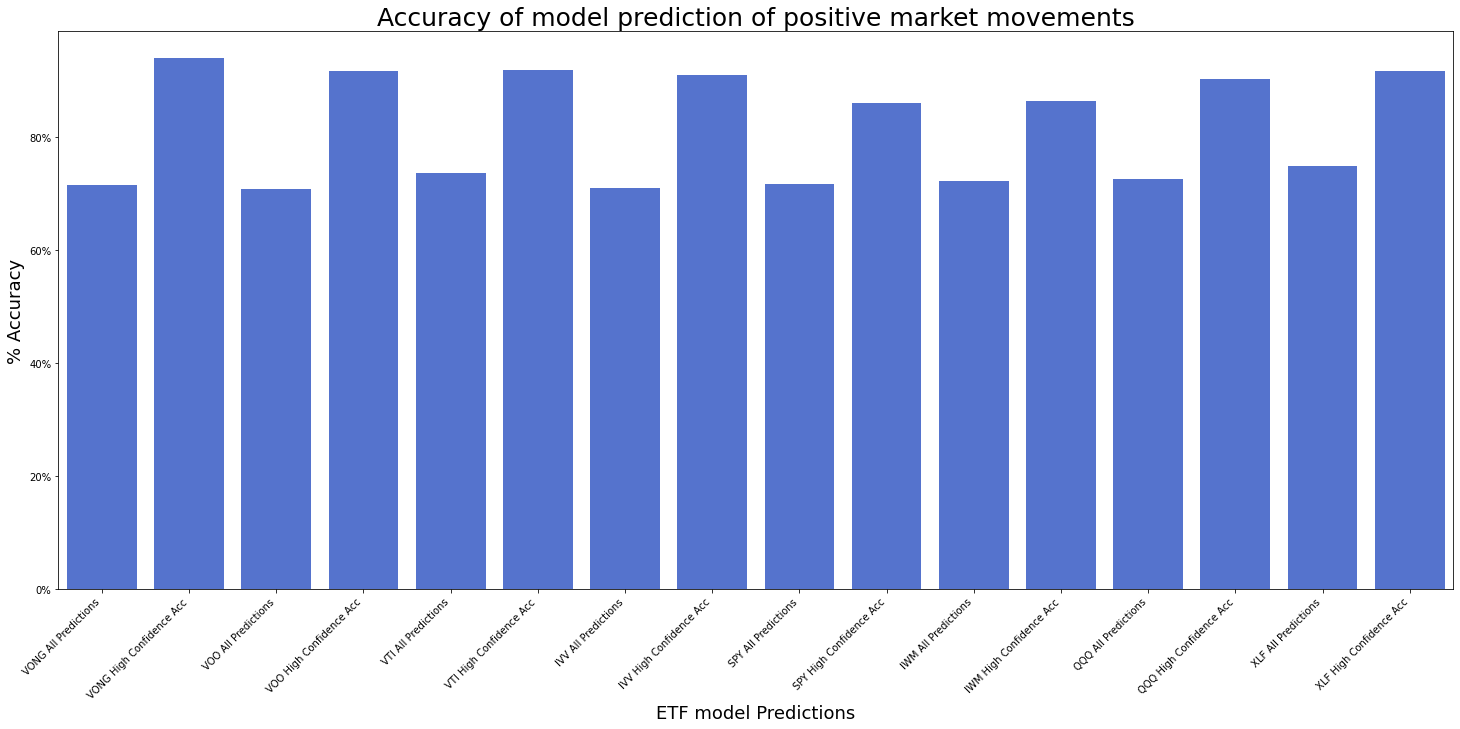

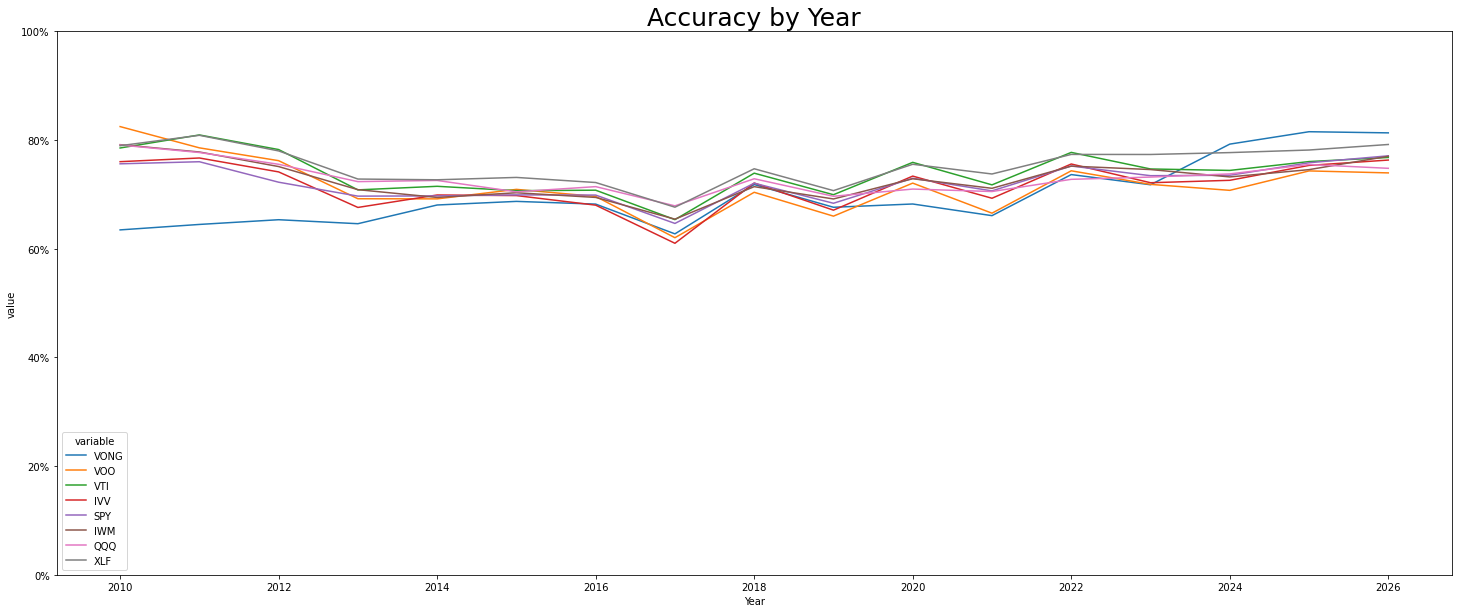

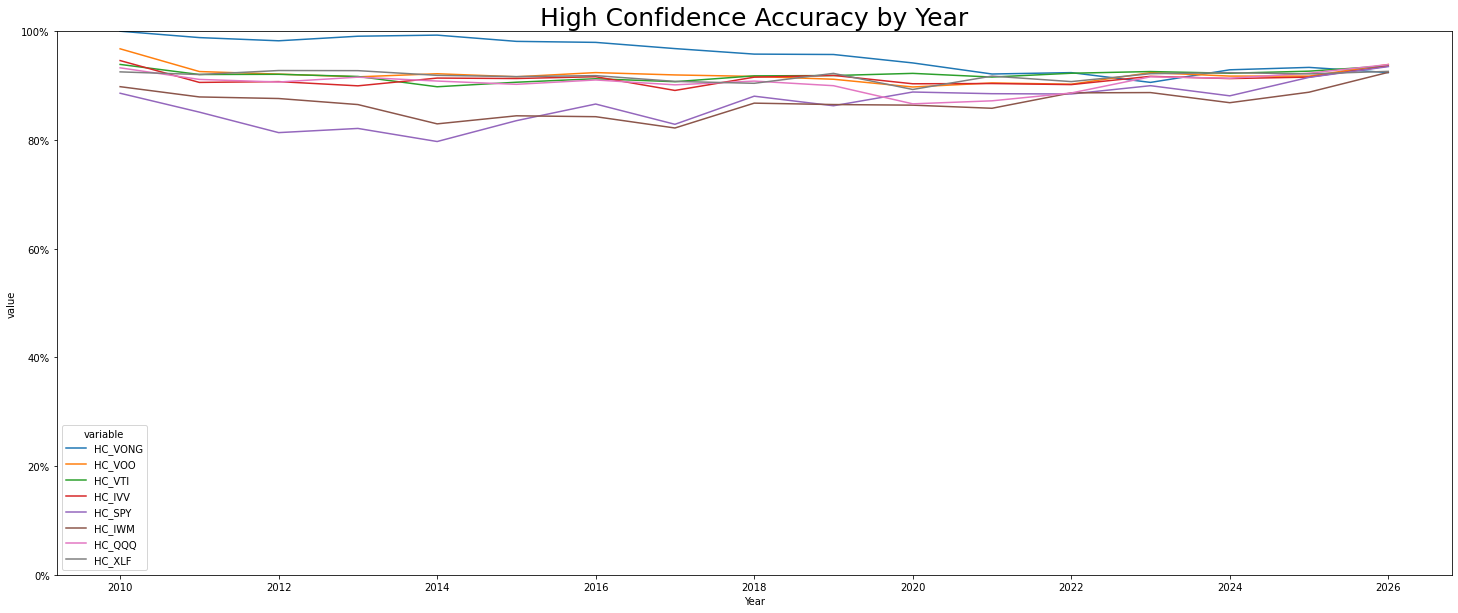

In [68]:
#Load and test DNN
DNN_Instance = DNN(ETL_Instance.xCols, ETL_Instance.yCols)
DNN_Instance.load_models(rf'F:\ETF_LSTM','DNN5')
predictions = DNN_Instance.get_predictions(ETL_Instance.x_data)
predictions.columns = ETL_Instance.y_threshold_data.columns[0:32]
DNN_Instance.show_accuracy_agg(ETL_Instance.df[ETL_Instance.yCols],predictions)
DNN_Instance.show_accuracy_yearly(ETL_Instance.df[ETL_Instance.yCols],predictions,ETL_Instance.df['date_time'])

Deep Q network is trained next.  Two types of reward environments are used.  One simply training over model returns, and one training on a customized point based reward system

In [ ]:
#Train DQN based on LSTM output
DQN_Instance = Q_Network()
DQN_Instance.build_model(predictions.values, ETL_INstance_LSTM.df[ETL_INstance_LSTM.modelActs].values, 1000000, window_size=1, num_episodes=10, batch_size=32)
DQN_Instance.save_model(rf'F:\ETF_LSTM\DQN_Model_LSTM4')
DQN_Instance.display_return_graphs(predictions.values,ETL_INstance_LSTM.df[ETL_INstance_LSTM.actCols],0.0001)


In [59]:
#Train DQNs
DQN_Instance = Q_Network()
DQN_Instance.build_model(predictions.values, ETL_Instance.df[ETL_Instance.modelActs].values, 1000000, window_size=1, num_episodes=10, batch_size=32)
DQN_Instance.save_model(rf'F:\ETF_LSTM\DQN_Model')
DQN_Instance.display_return_graphs(predictions.values,ETL_Instance.df[ETL_Instance.actCols],0.0001)


Episode 1/10, Total Reward: 1581200
Episode 2/10, Total Reward: 1613110
Episode 3/10, Total Reward: 1633180
Episode 4/10, Total Reward: 1623025
Episode 5/10, Total Reward: 1625570
Episode 6/10, Total Reward: 1630110
Episode 7/10, Total Reward: 1631370
Episode 8/10, Total Reward: 1626435
Episode 9/10, Total Reward: 1629930
Episode 10/10, Total Reward: 1637450


    Year         DQN      VONG       VOO       VTI       IVV       SPY  \
0   2010    1.125845  0.124035  0.121092  0.131720  0.119959  0.118469   
1   2011   65.543363  0.014675  0.030757  0.020987  0.030262  0.030582   
2   2012   14.193916  0.178193  0.165056  0.169384  0.163033  0.161737   
3   2013    5.870642  0.305111  0.287740  0.293008  0.285660  0.285276   
4   2014    8.001944  0.131507  0.147362  0.137401  0.147040  0.144948   
5   2015   13.993390  0.043016 -0.005357 -0.012326 -0.005163 -0.005566   
6   2016   14.243844  0.100796  0.152674  0.159939  0.152449  0.151153   
7   2017    4.232827  0.298323  0.213509  0.210573  0.211419  0.210405   
8   2018   22.390199 -0.046571 -0.071993 -0.073288 -0.071633 -0.072122   
9   2019   10.361692  0.386306  0.336169  0.330656  0.333514  0.334091   
10  2020  378.019542  0.735456  0.573888  0.594900  0.569576  0.566099   
11  2021   29.514396  0.271846  0.290000  0.260569  0.290225  0.289545   
12  2022  152.847031 -0.291403 -0.1811

In [10]:
#Train DQN based on market return
DQN_Instance_returns = Q_Network()
DQN_Instance_returns.build_model_returns(predictions.values, ETL_Instance.df[ETL_Instance.modelActs].values, 1000000, window_size=1, num_episodes=10, batch_size=32)
DQN_Instance_returns.save_model(rf'F:\ETF_LSTM\DQN_Model_Returns')
DQN_Instance_returns.display_graphs_ret_model(predictions.values,ETL_Instance.df[ETL_Instance.actCols],0.0001)


Episode 1/10, Total Reward: 288202136010176.0
Episode 2/10, Total Reward: 3.373764456642912e+16
Episode 3/10, Total Reward: 3.848219830155616e+16
Episode 4/10, Total Reward: 1.0760050999653002e+18
Episode 5/10, Total Reward: 2398018240.0
Episode 6/10, Total Reward: 16438093248.0
Episode 7/10, Total Reward: 29096234432.0
Episode 8/10, Total Reward: 7.797451278348938e+17
Episode 9/10, Total Reward: 135963044003264.0
Episode 10/10, Total Reward: 8.671899747776864e+16


    Year       DQN      VONG       VOO       VTI       IVV       SPY  \
0   2010 -0.014336  0.124035  0.121092  0.131720  0.119959  0.118469   
1   2011 -0.626257  0.014675  0.030757  0.020987  0.030262  0.030582   
2   2012 -0.646275  0.178193  0.165056  0.169384  0.163033  0.161737   
3   2013 -0.743598  0.305111  0.287740  0.293008  0.285660  0.285276   
4   2014 -0.700105  0.131507  0.147362  0.137401  0.147040  0.144948   
5   2015 -0.756175  0.043016 -0.005357 -0.012326 -0.005163 -0.005566   
6   2016 -0.746075  0.100796  0.152674  0.159939  0.152449  0.151153   
7   2017 -0.731535  0.298323  0.213509  0.210573  0.211419  0.210405   
8   2018 -0.636030 -0.046571 -0.071993 -0.073288 -0.071633 -0.072122   
9   2019 -0.682337  0.386306  0.336169  0.330656  0.333514  0.334091   
10  2020 -0.596318  0.735456  0.573888  0.594900  0.569576  0.566099   
11  2021 -0.670498  0.271846  0.290000  0.260569  0.290225  0.289545   
12  2022 -0.547788 -0.291403 -0.181162 -0.193592 -0.180912 -0.18

In [48]:
#Test DQN
DQN_Instance = Q_Network()
DQN_Instance.load_model(rf'F:\ETF_LSTM\DQN_Model')
DQN_Instance.display_return_graphs(predictions.values,ETL_Instance.df[ETL_Instance.actCols],0.0001)

    Year        DQN      VONG       VOO       VTI       IVV       SPY  \
0   2010   0.657650  0.124035  0.121092  0.131720  0.119959  0.118469   
1   2011  15.479513  0.014675  0.030757  0.020987  0.030262  0.030582   
2   2012   4.089506  0.178193  0.165056  0.169384  0.163033  0.161737   
3   2013   2.051603  0.305111  0.287740  0.293008  0.285660  0.285276   
4   2014   2.253139  0.131507  0.147362  0.137401  0.147040  0.144948   
5   2015   3.718081  0.043016 -0.005357 -0.012326 -0.005163 -0.005566   
6   2016   4.107929  0.100796  0.152674  0.159939  0.152449  0.151153   
7   2017   0.975063  0.298323  0.213509  0.210573  0.211419  0.210405   
8   2018   4.793660 -0.046571 -0.071993 -0.073288 -0.071633 -0.072122   
9   2019   3.213286  0.386306  0.336169  0.330656  0.333514  0.334091   
10  2020  52.164095  0.735456  0.573888  0.594900  0.569576  0.566099   
11  2021   5.030141  0.271846  0.290000  0.260569  0.290225  0.289545   
12  2022  20.456672 -0.291403 -0.181162 -0.193592 -

Trading is done utilizing the Alpaca trading environment through the Alpaca class

In [ ]:
#LSTM Trading Example
LSTM_Network_Instance = LSTM_Network(ETL_INstance_LSTM.xCols, ETL_INstance_LSTM.yCols,36)
LSTM_Network_Instance.load_models(rf'F:\ETF_LSTM','LSTN4')
DQN_Instance = Q_Network()
DQN_Instance.load_model(rf'F:\ETF_LSTM\DQN_Model_LSTM2')
Alpaca = AlpacaTrades(ETL_INstance_LSTM,DQN_Instance,LSTM_Network_Instance)
Alpaca.run()

In [58]:
DNN_Instance = DNN(ETL_Instance.xCols, ETL_Instance.yCols)
DNN_Instance.load_models(rf'F:\ETF_LSTM','DNN6')
DQN_Instance = Q_Network()
DQN_Instance.load_model(rf'F:\ETF_LSTM\DQN_Model2')
Alpaca = AlpacaTrades(ETL_Instance,DQN_Instance,DNN_Instance)
Alpaca.run()

Cash: 0.17, VONG: 0, VOO: 0, VTI: 0, IVV: 0, SPY: 0, IWM: 0, QQQ: 0, XLF: 100312.087223
Buy XLF
Your cash balance: $0.17
Cash: 0.17, VONG: 0, VOO: 0, VTI: 0, IVV: 0, SPY: 0, IWM: 0, QQQ: 0, XLF: 100312.087223


Conclusions:
The LSTM model takes significantly longer to setup/run creating a delayed environment not justified by mild improvements in the effectiveness.  A Deep Neural Network can be used effectively with movement, and volatility data included.
The Q-network trained on returns only provided underwhelming returns.  It created a largely volatile model by min-maxing the returns.  Training the model over a custom set of rules created an environment with good returns over the dataset it was trained on.
Implimenting the network on Alpaca trading proved relatively easy.  The algorithm can pull market movements, update projections, detmine actions, and perform them algorithmically through the API.